In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from src.config.path import PROCESS_PATH, RAW_PATH

In [17]:
df = pd.read_parquet(PROCESS_PATH / "flight.parquet", engine="pyarrow")
df

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,6.261616,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,7.676739,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,7.213987,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.425537,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,4.900079,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,8.788151,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,10.553163,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,10.579715,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,10.376503,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   flight                 209 non-null    int64  
 1   payload                209 non-null    float64
 2   route                  209 non-null    str    
 3   altitude_preset        209 non-null    str    
 4   date                   209 non-null    str    
 5   time_day               209 non-null    str    
 6   duration_s             209 non-null    float64
 7   total_distance_m       209 non-null    float64
 8   wind_speed_mean        209 non-null    float64
 9   wind_speed_std         209 non-null    float64
 10  wind_x_mean            209 non-null    float64
 11  wind_y_mean            209 non-null    float64
 12  speed_mean             209 non-null    float64
 13  speed_max              209 non-null    float64
 14  velocity_mag_mean      209 non-null    float64
 15  velocity_mag_max 

In [13]:
df.columns

Index(['flight', 'payload', 'route', 'altitude_preset', 'date', 'time_day',
       'duration_s', 'total_distance_m', 'wind_speed_mean', 'wind_speed_std',
       'wind_x_mean', 'wind_y_mean', 'speed_mean', 'speed_max',
       'velocity_mag_mean', 'velocity_mag_max', 'acceleration_mag_mean',
       'acceleration_mag_std', 'battery_voltage_mean', 'battery_voltage_min',
       'max_height_agl', 'final_height_agl', 'energy_consumed_Wh',
       'battery_needed_mAh', 'landing_offset_flag'],
      dtype='str')

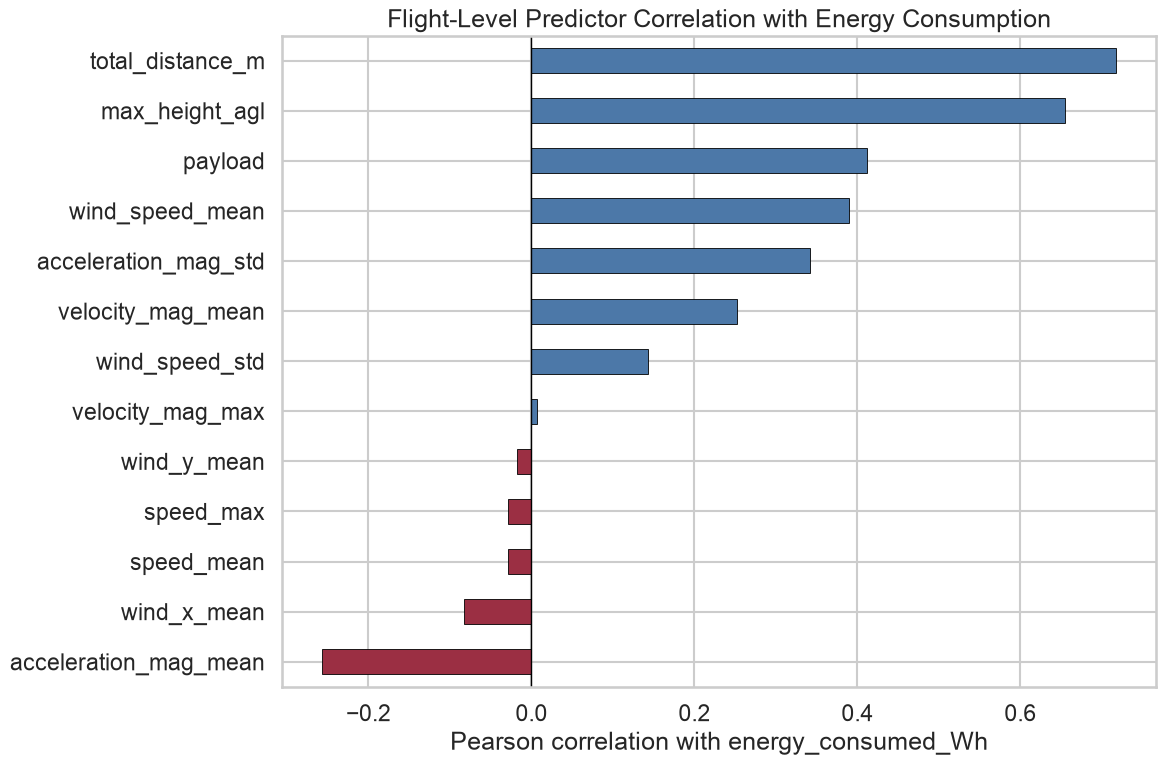

In [18]:
# Use the same 13 predictors as the regression models in train.ipynb.
feature_cols = [
    "total_distance_m",
    "max_height_agl",
    "payload",
    "wind_speed_mean",
    "wind_speed_std",
    "wind_x_mean",
    "wind_y_mean",
    "speed_mean",
    "speed_max",
    "velocity_mag_mean",
    "velocity_mag_max",
    "acceleration_mag_mean",
    "acceleration_mag_std",
]
target = "energy_consumed_Wh"
figure_path = PROCESS_PATH.parents[1] / "Paper" / "pic"
figure_path.mkdir(parents=True, exist_ok=True)

model_corr = df[feature_cols + [target]].corr(method="pearson")
target_corr = model_corr[target].drop(target).sort_values()
bar_colors = ["#9B2F43" if value < 0 else "#4C78A8" for value in target_corr]

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 8))
target_corr.plot(
    kind="barh",
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_title("Flight-Level Predictor Correlation with Energy Consumption")
ax.set_xlabel("Pearson correlation with energy_consumed_Wh")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(figure_path / "eda_target_correlation.png", dpi=200, bbox_inches="tight")
plt.show()


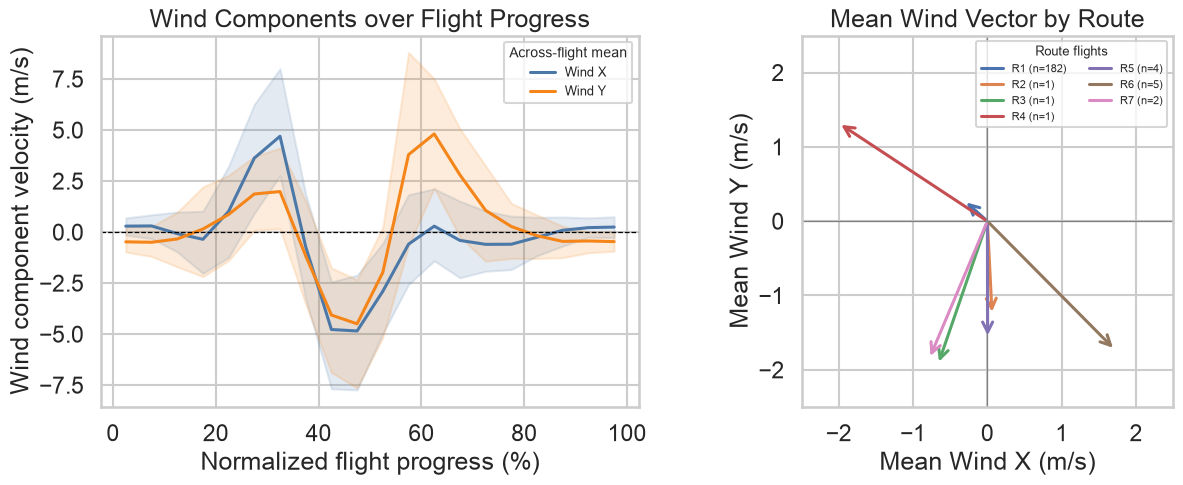

,route,wind_x_mean,wind_y_mean,flights
0,R1,-0.309808,0.276390,182
1,R2,0.062744,-1.257258,1
2,R3,-0.663277,-1.925686,1
3,R4,-1.998105,1.317073,1
4,R5,0.003351,-1.575097,4
5,R6,1.716795,-1.730805,5
6,R7,-0.781137,-1.848136,2


In [19]:
# Analyze wind patterns over normalized flight progress and across complete routes.
mission_routes = [f"R{i}" for i in range(1, 8)]
wind_columns = ["flight", "route", "time", "wind_speed", "wind_angle"]
wind_telemetry = pd.read_parquet(
    RAW_PATH / "drone.parquet", columns=wind_columns, engine="pyarrow"
)
wind_telemetry = (
    wind_telemetry.loc[wind_telemetry["route"].isin(mission_routes)]
    .sort_values(["flight", "time"])
    .copy()
)
wind_telemetry["wind_x"] = wind_telemetry["wind_speed"] * np.sin(
    np.deg2rad(wind_telemetry["wind_angle"])
)
wind_telemetry["wind_y"] = wind_telemetry["wind_speed"] * np.cos(
    np.deg2rad(wind_telemetry["wind_angle"])
)

flight_start = wind_telemetry.groupby("flight")["time"].transform("min")
flight_end = wind_telemetry.groupby("flight")["time"].transform("max")
wind_telemetry["flight_progress_pct"] = (
    100 * (wind_telemetry["time"] - flight_start) / (flight_end - flight_start)
)
wind_telemetry["progress_bin"] = np.minimum(
    (wind_telemetry["flight_progress_pct"] // 5).astype(int), 19
)
wind_telemetry["progress_center_pct"] = 5 * wind_telemetry["progress_bin"] + 2.5

# Average within each flight first so that long flights do not dominate the trend.
flight_progress_wind = (
    wind_telemetry.groupby(
        ["flight", "route", "progress_center_pct"], as_index=False
    )[["wind_x", "wind_y"]]
    .mean()
)
wind_progress = (
    flight_progress_wind.groupby("progress_center_pct", as_index=False)
    .agg(
        wind_x_mean=("wind_x", "mean"),
        wind_x_q25=("wind_x", lambda values: values.quantile(0.25)),
        wind_x_q75=("wind_x", lambda values: values.quantile(0.75)),
        wind_y_mean=("wind_y", "mean"),
        wind_y_q25=("wind_y", lambda values: values.quantile(0.25)),
        wind_y_q75=("wind_y", lambda values: values.quantile(0.75)),
    )
)
flight_wind = (
    wind_telemetry.groupby(["flight", "route"], as_index=False)[["wind_x", "wind_y"]]
    .mean()
)
route_wind = (
    flight_wind.groupby("route", as_index=False)
    .agg(
        wind_x_mean=("wind_x", "mean"),
        wind_y_mean=("wind_y", "mean"),
        flights=("flight", "size"),
    )
    .set_index("route")
    .reindex(mission_routes)
    .reset_index()
)

wind_colors = {"wind_x": "#4C78A8", "wind_y": "#F58518"}
route_palette = dict(zip(mission_routes, sns.color_palette("deep", len(mission_routes))))
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for component, label in [("wind_x", "Wind X"), ("wind_y", "Wind Y")]:
    axes[0].plot(
        wind_progress["progress_center_pct"],
        wind_progress[f"{component}_mean"],
        color=wind_colors[component],
        linewidth=2.2,
        label=label,
    )
    axes[0].fill_between(
        wind_progress["progress_center_pct"],
        wind_progress[f"{component}_q25"],
        wind_progress[f"{component}_q75"],
        color=wind_colors[component],
        alpha=0.15,
    )
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.9)
axes[0].set_title("Wind Components over Flight Progress")
axes[0].set_xlabel("Normalized flight progress (%)")
axes[0].set_ylabel("Wind component velocity (m/s)")
axes[0].legend(title="Across-flight mean", fontsize=9, title_fontsize=10)

axes[1].axhline(0, color="gray", linewidth=0.9)
axes[1].axvline(0, color="gray", linewidth=0.9)
for row in route_wind.itertuples(index=False):
    color = route_palette[row.route]
    axes[1].annotate(
        "",
        xy=(row.wind_x_mean, row.wind_y_mean),
        xytext=(0, 0),
        arrowprops={"arrowstyle": "->", "color": color, "linewidth": 2.2},
    )
    axes[1].plot([], [], color=color, linewidth=2.2, label=f"{row.route} (n={row.flights})")
vector_limit = 1.25 * route_wind[["wind_x_mean", "wind_y_mean"]].abs().to_numpy().max()
axes[1].set_xlim(-vector_limit, vector_limit)
axes[1].set_ylim(-vector_limit, vector_limit)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Mean Wind Vector by Route")
axes[1].set_xlabel("Mean Wind X (m/s)")
axes[1].set_ylabel("Mean Wind Y (m/s)")
axes[1].legend(title="Route flights", ncol=2, fontsize=8, title_fontsize=9)

fig.tight_layout()
fig.savefig(figure_path / "eda_wind_components.png", dpi=200, bbox_inches="tight")
plt.show()
route_wind

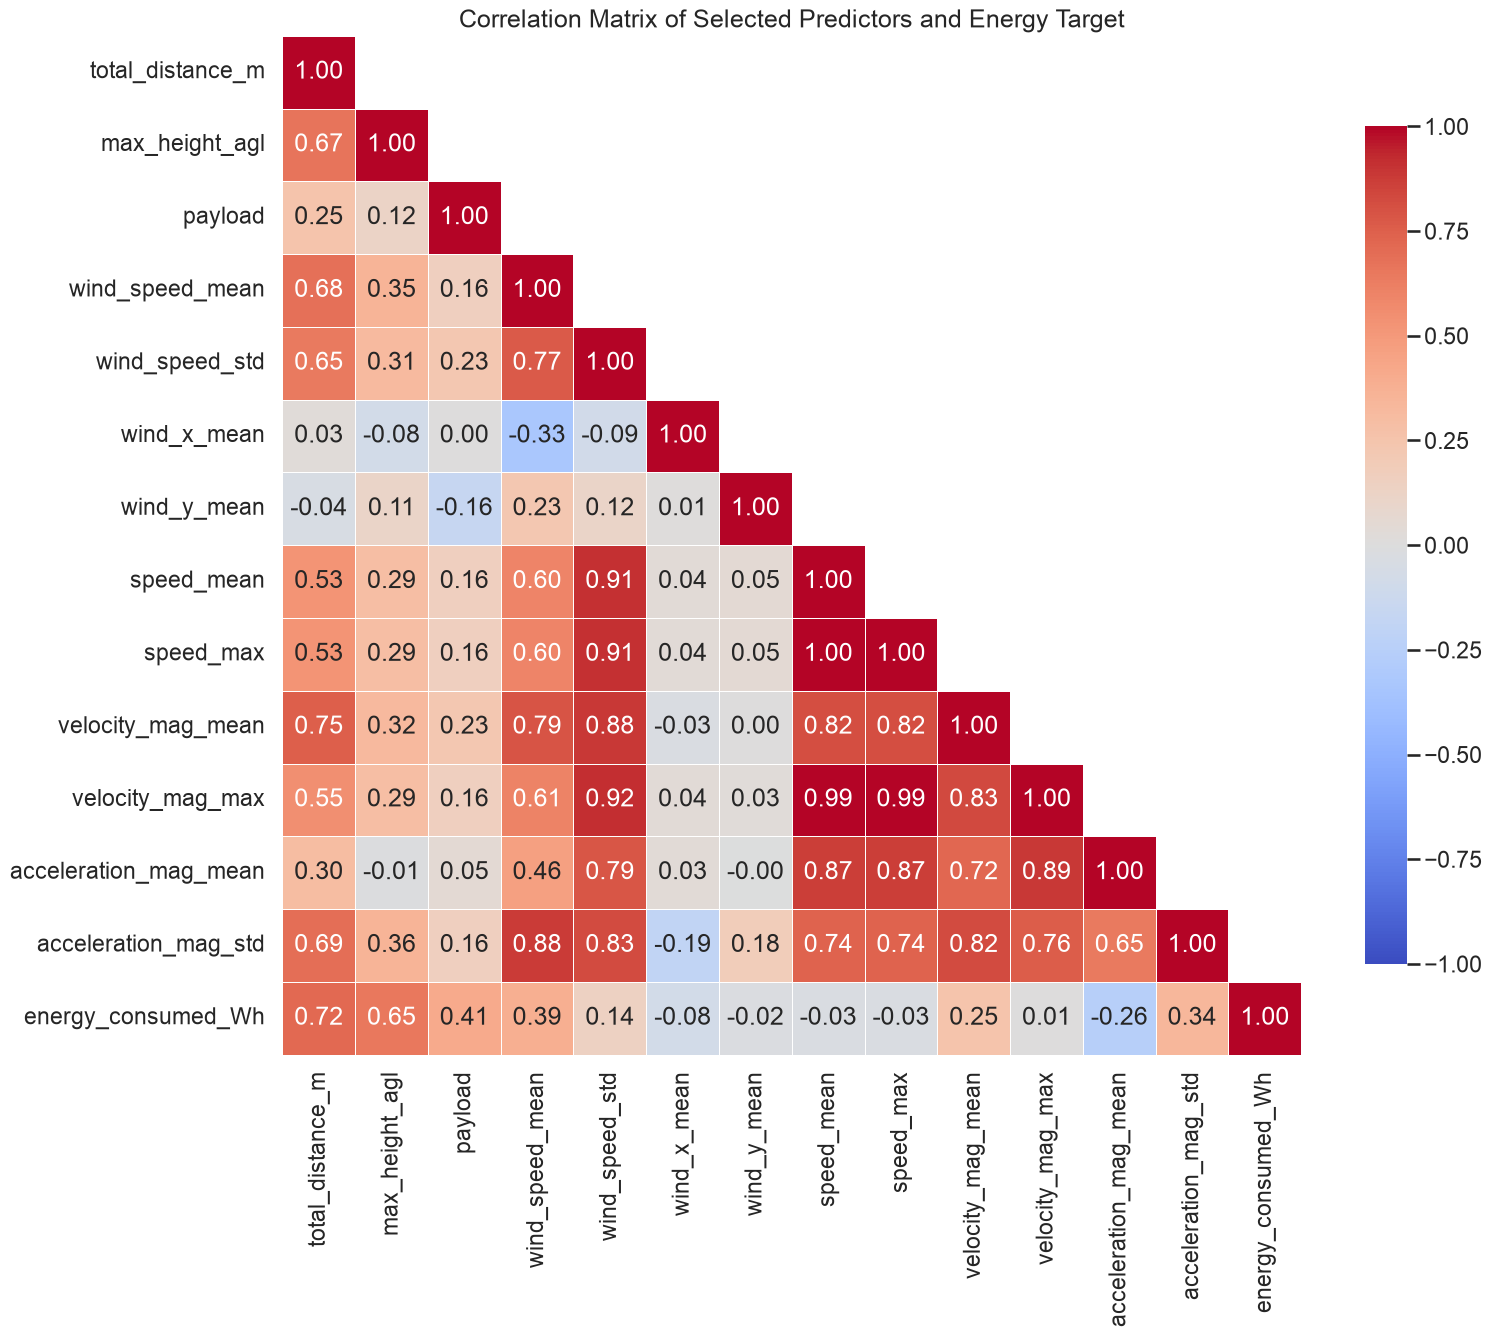

In [20]:
# Plot the lower triangle for the 13 predictors and the energy target.
mask = np.triu(np.ones_like(model_corr, dtype=bool), k=1)

sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    model_corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Correlation Matrix of Selected Predictors and Energy Target")
fig.tight_layout()
fig.savefig(figure_path / "eda_correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

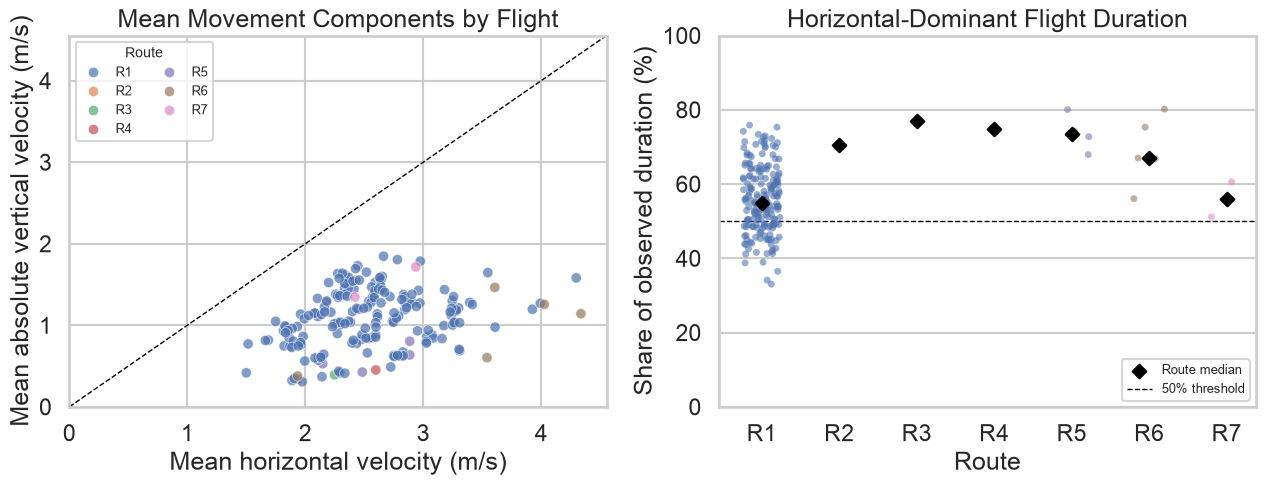

Mean horizontal velocity exceeds mean absolute vertical velocity for 196/196 flights.
Median horizontal-dominant duration: 56.0%.
Flights above the 50% duration threshold: 144/196.


In [21]:
# Evaluate horizontal and vertical movement for every complete mission flight.
mission_routes = [f"R{i}" for i in range(1, 8)]
motion_columns = [
    "flight", "route", "time", "velocity_x", "velocity_y", "velocity_z"
]
telemetry = pd.read_parquet(
    RAW_PATH / "drone.parquet", columns=motion_columns, engine="pyarrow"
)
mission_telemetry = (
    telemetry.loc[telemetry["route"].isin(mission_routes)]
    .sort_values(["flight", "time"])
    .copy()
)
mission_telemetry["horizontal_velocity"] = np.hypot(
    mission_telemetry["velocity_x"], mission_telemetry["velocity_y"]
)
mission_telemetry["absolute_vertical_velocity"] = mission_telemetry["velocity_z"].abs()
mission_telemetry["dt_s"] = (
    mission_telemetry.groupby("flight")["time"].diff().fillna(0).clip(lower=0)
)
mission_telemetry["horizontal_dominant_dt_s"] = mission_telemetry["dt_s"] * (
    mission_telemetry["horizontal_velocity"]
    > mission_telemetry["absolute_vertical_velocity"]
)

flight_motion = (
    mission_telemetry.groupby(["flight", "route"], as_index=False)
    .agg(
        mean_horizontal_velocity=("horizontal_velocity", "mean"),
        mean_absolute_vertical_velocity=("absolute_vertical_velocity", "mean"),
        duration_s=("dt_s", "sum"),
        horizontal_dominant_duration_s=("horizontal_dominant_dt_s", "sum"),
    )
)
flight_motion["horizontal_dominant_share_pct"] = (
    100
    * flight_motion["horizontal_dominant_duration_s"]
    / flight_motion["duration_s"]
)

route_palette = dict(zip(mission_routes, sns.color_palette("deep", len(mission_routes))))
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.scatterplot(
    data=flight_motion,
    x="mean_horizontal_velocity",
    y="mean_absolute_vertical_velocity",
    hue="route",
    hue_order=mission_routes,
    palette=route_palette,
    alpha=0.70,
    s=55,
    edgecolor="white",
    linewidth=0.5,
    ax=axes[0],
)
motion_limit = 1.05 * max(
    flight_motion["mean_horizontal_velocity"].max(),
    flight_motion["mean_absolute_vertical_velocity"].max(),
)
axes[0].plot([0, motion_limit], [0, motion_limit], "--", color="black", linewidth=1)
axes[0].set_xlim(0, motion_limit)
axes[0].set_ylim(0, motion_limit)
axes[0].set_title("Mean Movement Components by Flight")
axes[0].set_xlabel("Mean horizontal velocity (m/s)")
axes[0].set_ylabel("Mean absolute vertical velocity (m/s)")
axes[0].legend(title="Route", ncol=2, fontsize=9, title_fontsize=10)

sns.stripplot(
    data=flight_motion,
    x="route",
    y="horizontal_dominant_share_pct",
    order=mission_routes,
    hue="route",
    hue_order=mission_routes,
    palette=route_palette,
    jitter=0.24,
    alpha=0.58,
    size=5,
    legend=False,
    ax=axes[1],
)
route_medians = (
    flight_motion.groupby("route")["horizontal_dominant_share_pct"]
    .median()
    .reindex(mission_routes)
)
axes[1].scatter(
    np.arange(len(mission_routes)),
    route_medians.values,
    marker="D",
    s=48,
    color="black",
    label="Route median",
    zorder=4,
)
axes[1].axhline(50, color="black", linestyle="--", linewidth=1, label="50% threshold")
axes[1].set_ylim(0, 100)
axes[1].set_title("Horizontal-Dominant Flight Duration")
axes[1].set_xlabel("Route")
axes[1].set_ylabel("Share of observed duration (%)")
axes[1].legend(fontsize=9, loc="lower right")

fig.tight_layout()
fig.savefig(
    figure_path / "eda_horizontal_flight_tendency.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

horizontal_mean_count = (
    flight_motion["mean_horizontal_velocity"]
    > flight_motion["mean_absolute_vertical_velocity"]
).sum()
horizontal_majority_count = (flight_motion["horizontal_dominant_share_pct"] > 50).sum()
print(
    f"Mean horizontal velocity exceeds mean absolute vertical velocity for "
    f"{horizontal_mean_count}/{len(flight_motion)} flights."
)
print(
    f"Median horizontal-dominant duration: "
    f"{flight_motion['horizontal_dominant_share_pct'].median():.1f}%."
)
print(
    f"Flights above the 50% duration threshold: "
    f"{horizontal_majority_count}/{len(flight_motion)}."
)

In [22]:
del df
gc.collect()
%whos

Variable                    Type         Data/Info
--------------------------------------------------
PROCESS_PATH                PosixPath    /Users/nguyentantai/Deskt<...>er-predict/data/processed
RAW_PATH                    PosixPath    /Users/nguyentantai/Deskt<...>ne-Power-predict/data/raw
ax                          Axes         Axes(0.187101,0.218018;0.636819x0.727794)
axes                        ndarray      2: 2 elems, type `object`, 16 bytes
bar_colors                  list         n=13
color                       tuple        n=3
column                      str          wind_y_mean
component                   str          wind_y
feature_cols                list         n=13
fig                         Figure       Figure(1300x520)
figure_path                 PosixPath    /Users/nguyentantai/Deskt<...>e-Power-predict/Paper/pic
flight_end                  Series       Shape: (247601,)
flight_motion               DataFrame    Shape: (196, 7)
flight_progress_wind        DataFram